In [1]:
import sys, torch
print("python:", sys.executable)
print("torch:", torch.__version__)
print("torch file:", torch.__file__)
print("cuda built:", torch.backends.cuda.is_built())
print("torch.version.cuda:", torch.version.cuda)
print("is_available:", torch.cuda.is_available())
print("device_count:", torch.cuda.device_count())

python: c:\Users\Radimon\AppData\Local\Programs\Python\Python314\python.exe
torch: 2.10.0+cpu
torch file: c:\Users\Radimon\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\__init__.py
cuda built: False
torch.version.cuda: None
is_available: False
device_count: 0


In [2]:
import pandas as pd

df = pd.read_parquet("../data/processed/sapporo_density.parquet")


In [3]:
# 1) (d,t,x,y) 必須唯一
dup = df.duplicated(["d","t","x","y"]).sum()
print("dup:", dup)

# 2) 範圍檢查
print(df[["d","t","x","y","count"]].describe())

# 3) 每天/每時段是否齊全（至少 t 應該 0~47）
print(df["t"].min(), df["t"].max(), df["t"].nunique())
print(df["d"].min(), df["d"].max(), df["d"].nunique())

dup: 0
                  d             t             x             y         count
count  6.024808e+06  6.024808e+06  6.024808e+06  6.024808e+06  6.024808e+06
mean   3.646489e+01  2.471382e+01  3.140973e+01  1.493889e+02  3.063422e+00
std    2.146972e+01  1.252862e+01  2.165999e+01  3.666576e+01  8.499277e+00
min    0.000000e+00  0.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00
25%    1.800000e+01  1.500000e+01  2.000000e+01  1.410000e+02  1.000000e+00
50%    3.600000e+01  2.500000e+01  3.000000e+01  1.550000e+02  2.000000e+00
75%    5.500000e+01  3.500000e+01  4.000000e+01  1.710000e+02  4.000000e+00
max    7.400000e+01  4.700000e+01  9.990000e+02  9.990000e+02  1.201000e+03
0 47 48
0 74 75


In [4]:
# 看 x/y 的分位數（很直觀）
print("x quantiles:", df["x"].quantile([0, .5, .9, .99, .999, 1]))
print("y quantiles:", df["y"].quantile([0, .5, .9, .99, .999, 1]))

# 看極端 x 或 y 的資料量有多少
X_TH = int(df["x"].quantile(0.999))
Y_TH = int(df["y"].quantile(0.999))

print("rows with x>=X_TH:", (df["x"]>=X_TH).sum())
print("rows with y>=Y_TH:", (df["y"]>=Y_TH).sum())

# 看那些極端點的總人流量(很重要，因為你有 count)
print("total count in x>=X_TH:", df.loc[df["x"]>=X_TH, "count"].sum())
print("total count in y>=Y_TH:", df.loc[df["y"]>=Y_TH, "count"].sum())

#!!!先不要刪除離群值!!!

x quantiles: 0.000      1.0
0.500     30.0
0.900     50.0
0.990     88.0
0.999    185.0
1.000    999.0
Name: x, dtype: float64
y quantiles: 0.000      1.0
0.500    155.0
0.900    185.0
0.990    197.0
0.999    200.0
1.000    999.0
Name: y, dtype: float64
rows with x>=X_TH: 6043
rows with y>=Y_TH: 15304
total count in x>=X_TH: 454990
total count in y>=Y_TH: 467026


格網 (24, 151) 共 3544 筆記錄
涵蓋天數: 75，時段數: 48


C:\Users\Radimon\AppData\Local\Temp\ipykernel_41472\853037424.py:88: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Radimon\AppData\Local\Temp\ipykernel_41472\853037424.py:88: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Radimon\AppData\Local\Temp\ipykernel_41472\853037424.py:88: UserWarning: Glyph 23526 (\N{CJK UNIFIED IDEOGRAPH-5BE6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Radimon\AppData\Local\Temp\ipykernel_41472\853037424.py:88: UserWarning: Glyph 38555 (\N{CJK UNIFIED IDEOGRAPH-969B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Radimon\AppData\Local\Temp\ipykernel_41472\853037424.py:89: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.savefig(f"grid_{TARGET_X}_{TARGET_Y}_trend.png", dpi=150, bbox_inches="tight")
C:\Users\Radimon\AppData\

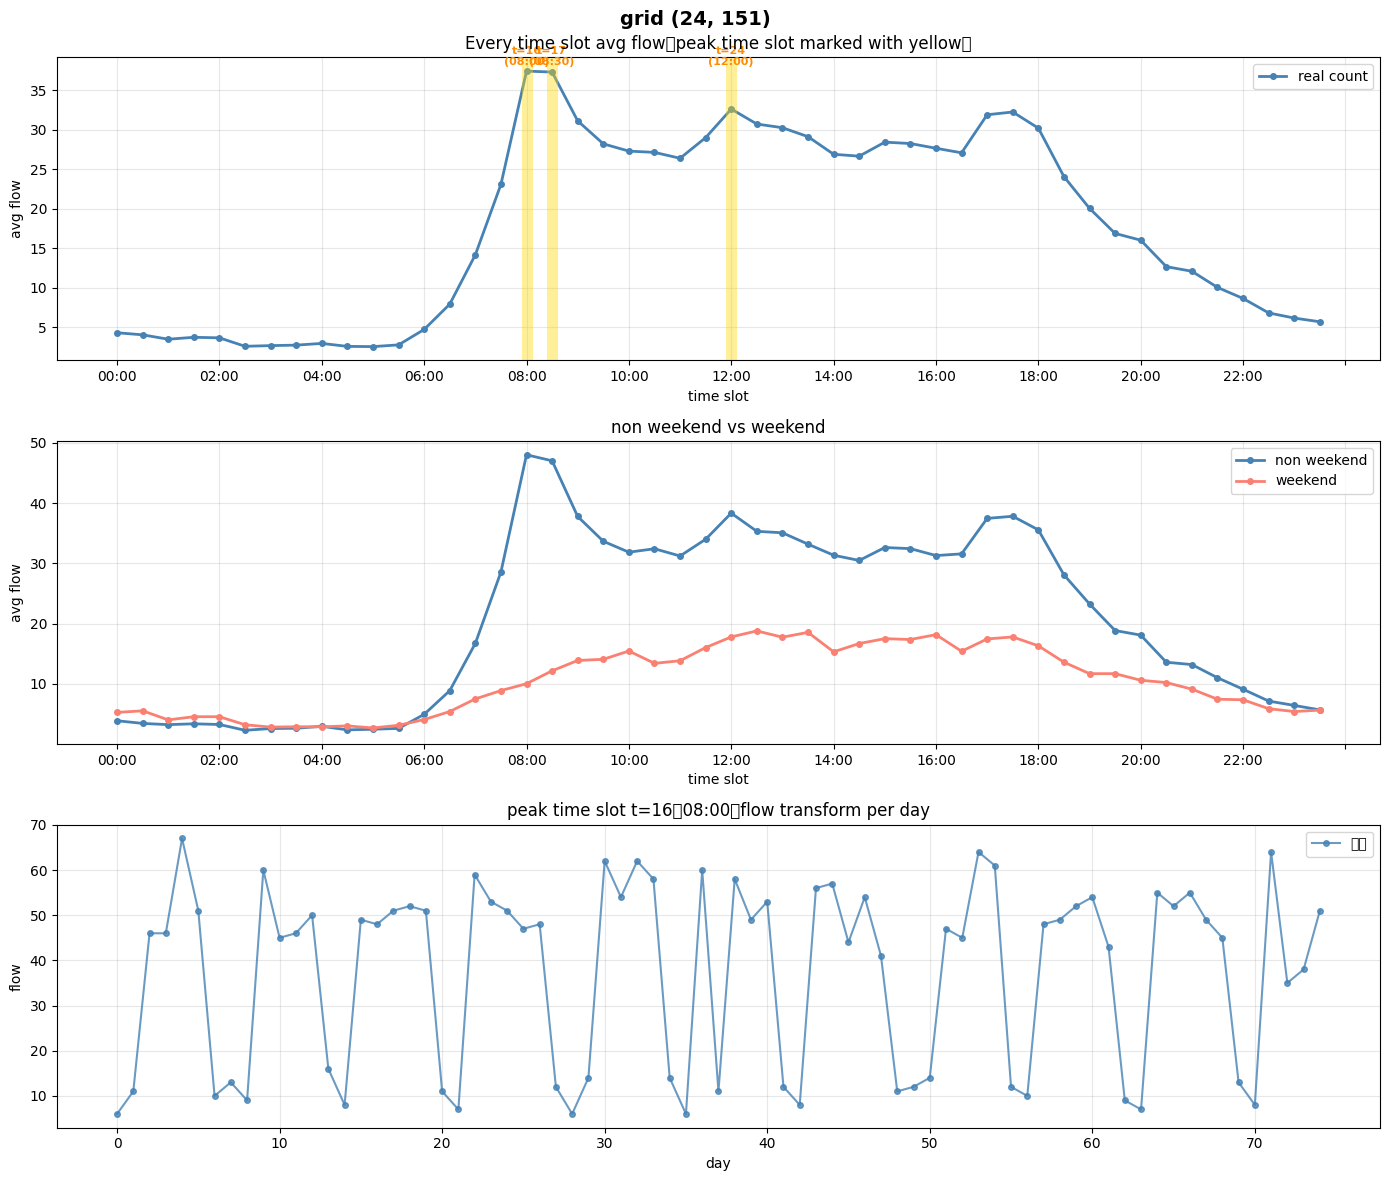


=== 尖峰時段 Top 5 ===


In [5]:
# ============================================================
# 單一格網的人流趨勢分析 - 判斷尖峰時段
# ============================================================

TARGET_X = 24 
TARGET_Y = 151 

df_pred = df.copy()
# ── 1. 篩選該格網的所有資料 ──────────────────────────────────
mask = (df_pred["x"] == TARGET_X) & (df_pred["y"] == TARGET_Y)
df_grid = df_pred[mask].copy()

print(f"格網 ({TARGET_X}, {TARGET_Y}) 共 {len(df_grid)} 筆記錄")
print(f"涵蓋天數: {df_grid['d'].nunique()}，時段數: {df_grid['t'].nunique()}")

# ── 2. 每個時段的平均人流（跨所有天）→ 判斷尖峰時段 ──────────
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle(f"grid ({TARGET_X}, {TARGET_Y})", fontsize=14, fontweight="bold")

# ── 圖1：每時段平均人流（預測 vs 真實）──────────────────────
ax1 = axes[0]
t_avg_true = df_grid.groupby("t")["count"].mean()
#t_avg_pred = df_grid.groupby("t")["score"].mean()

ax1.plot(t_avg_true.index, t_avg_true.values, "o-", color="steelblue", 
         linewidth=2, markersize=4, label="real count")
#ax1.plot(t_avg_pred.index, t_avg_pred.values, "s--", color="tomato", linewidth=2, markersize=4, label="預測 score")

# 標記尖峰時段（前3高）
top3_t = t_avg_true.nlargest(3).index
for t in top3_t:
    ax1.axvline(x=t, color="gold", alpha=0.4, linewidth=8)
    ax1.text(t, t_avg_true.max() * 1.02, f"t={t}\n({t//2:02d}:{(t%2)*30:02d})", 
             ha="center", fontsize=8, color="darkorange", fontweight="bold")

ax1.set_title("Every time slot avg flow（peak time slot marked with yellow）")
ax1.set_xlabel("time slot")
ax1.set_ylabel("avg flow")
ax1.legend()
ax1.grid(alpha=0.3)
# x 軸標示時間
ax1.xaxis.set_major_locator(ticker.MultipleLocator(4))
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f"{int(x)//2:02d}:{(int(x)%2)*30:02d}" if 0 <= x <= 47 else ""))

# ── 圖2：平日 vs 假日 各時段比較 ────────────────────────────
ax2 = axes[1]
df_grid["date"] = pd.to_datetime("2019-09-15") + pd.to_timedelta(df_grid["d"], unit="D")
df_grid["weekday"] = df_grid["date"].dt.weekday
df_grid["is_weekend"] = (df_grid["weekday"] >= 5).astype(int)

for is_wk, label, color in [(0, "non weekend", "steelblue"), (1, "weekend", "salmon")]:
    sub = df_grid[df_grid["is_weekend"] == is_wk]
    if len(sub) == 0:
        continue
    avg = sub.groupby("t")["count"].mean()
    ax2.plot(avg.index, avg.values, "o-", color=color,
             linewidth=2, markersize=4, label=label)

ax2.set_title("non weekend vs weekend")
ax2.set_xlabel("time slot")
ax2.set_ylabel("avg flow")
ax2.legend()
ax2.grid(alpha=0.3)
ax2.xaxis.set_major_locator(ticker.MultipleLocator(4))
ax2.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f"{int(x)//2:02d}:{(int(x)%2)*30:02d}" if 0 <= x <= 47 else ""))

# ── 圖3：時間序列（每天的某尖峰時段人流變化）───────────────
ax3 = axes[2]
peak_t = int(t_avg_true.idxmax())   # 最高峰時段
df_peak = df_grid[df_grid["t"] == peak_t].sort_values("d")

ax3.plot(df_peak["d"], df_peak["count"], "o-", color="steelblue",
         linewidth=1.5, markersize=4, label="實際", alpha=0.8)
#ax3.plot(df_peak["d"], df_peak["score"], "s--", color="tomato", linewidth=1.5, markersize=4, label="預測", alpha=0.8)

ax3.set_title(f"peak time slot t={peak_t}（{peak_t//2:02d}:{(peak_t%2)*30:02d}）flow transform per day")
ax3.set_xlabel("day")
ax3.set_ylabel("flow")
ax3.legend()
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"grid_{TARGET_X}_{TARGET_Y}_trend.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 3. 印出尖峰時段摘要 ──────────────────────────────────────
print("\n=== 尖峰時段 Top 5 ===")
top5 = t_avg_true.nlargest(5).reset_index()
top5.columns = ["t", "avg_count"]
top5["時間"] = top5["t"].apply(lambda x: f"{x//2:02d}:{(x%2)*30:02d}")
#top5["預測平均"] = top5["t"].map(t_avg_pred).round(2)
top5["avg_count"] = top5["avg_count"].round(2)
#print(top5[["時間", "t", "avg_count", "預測平均"]].to_string(index=False))

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap

colors = ['#00000000', '#fff5f0', '#fee0d2', '#fcbba1', '#fc9272', 
          '#fb6a4a', '#ef3b2c', '#cb181d', '#a50f15', '#67000d']
cmap = LinearSegmentedColormap.from_list('heat', colors, N=256)

# 確保型別
for c in ["d","t","x","y","count"]:
    df[c] = df[c].astype(int)

d_min, d_max = int(df["d"].min()), int(df["d"].max())
t_min, t_max = int(df["t"].min()), int(df["t"].max())
x_max, y_max = int(df["x"].max()), int(df["y"].max())

# plt視窗大小，可以不被離群值影響圖表
x_lo, x_hi = df["x"].quantile([0.001, 0.999])
y_lo, y_hi = df["y"].quantile([0.001, 0.999])

x_lo, x_hi = int(np.floor(x_lo)), int(np.ceil(x_hi))
y_lo, y_hi = int(np.floor(y_lo)), int(np.ceil(y_hi))
print("crop window:", x_lo, x_hi, y_lo, y_hi)


# 讓 (d,t) 查詢更快
df_idx = df.set_index(["d","t"]).sort_index()

def _subset(d, t):
    """回傳某個(d,t)的子表（統一成 DataFrame）"""
    try:
        sub = df_idx.loc[(d, t)]
    except KeyError:
        return None
    if isinstance(sub, pd.Series):
        sub = sub.to_frame().T
    return sub.reset_index(drop=True)  # columns: x,y,count


def build_grid_cropped(d, t, x_lo, x_hi, y_lo, y_hi):
    sub = _subset(d, t)
    grid = np.zeros((y_hi - y_lo + 1, x_hi - x_lo + 1), dtype=np.float32)

    if sub is None or len(sub) == 0:
        return grid, 0

    # 只取視窗內
    m = sub["x"].between(x_lo, x_hi) & sub["y"].between(y_lo, y_hi)
    sub = sub.loc[m]
    if len(sub) == 0:
        return grid, 0

    xs = sub["x"].to_numpy() - x_lo
    ys = sub["y"].to_numpy() - y_lo
    cs = sub["count"].to_numpy()

    grid[ys, xs] = cs
    return grid, int(cs.sum())


def draw(d, t, log1p=False):
    grid, total = build_grid_cropped(d, t, x_lo, x_hi, y_lo, y_hi)
    show = np.log1p(grid) if log1p else grid

    plt.figure(figsize=(8,6))
    plt.imshow(show, origin="lower", aspect="auto",
               extent=[x_lo, x_hi, y_lo, y_hi], # 顯示原座標
               cmap=cmap,                
               interpolation="nearest")  
    plt.colorbar(label="log1p(count)" if log1p else "count")
    plt.title(f"Sapporo crowd density heatmap | d={d}, t={t} | total(in window)={total}")
    plt.xlabel("x"); plt.ylabel("y")
    plt.show()


# --- 互動控制（拉桿） ---
d_slider = widgets.IntSlider(value=d_min, min=d_min, max=d_max, step=1, description="d", continuous_update=True)
t_slider = widgets.IntSlider(value=t_min, min=t_min, max=t_max, step=1, description="t", continuous_update=True)
log_chk  = widgets.Checkbox(value=False, description="log1p", indent=False)

ui = widgets.HBox([d_slider, t_slider, log_chk])
out = widgets.interactive_output(draw, {"d": d_slider, "t": t_slider, "log1p": log_chk})

display(ui, out)


crop window: 1 185 2 200


Output()

findfont: Font family 'Noto Sans CJK TC' not found.
findfont: Font family 'Noto Sans CJK TC' not found.
findfont: Font family 'Noto Sans CJK TC' not found.
findfont: Font family 'Noto Sans CJK TC' not found.
findfont: Font family 'Noto Sans CJK TC' not found.
findfont: Font family 'Noto Sans CJK TC' not found.
findfont: Font family 'Noto Sans CJK TC' not found.
findfont: Font family 'Noto Sans CJK TC' not found.
findfont: Font family 'Noto Sans CJK TC' not found.
findfont: Font family 'Noto Sans CJK TC' not found.
findfont: Font family 'Noto Sans CJK TC' not found.
findfont: Font family 'Noto Sans CJK TC' not found.
findfont: Font family 'Noto Sans CJK TC' not found.
findfont: Font family 'Noto Sans CJK TC' not found.
findfont: Font family 'Noto Sans CJK TC' not found.
findfont: Font family 'Noto Sans CJK TC' not found.
findfont: Font family 'Noto Sans CJK TC' not found.
findfont: Font family 'Noto Sans CJK TC' not found.
findfont: Font family 'Noto Sans CJK TC' not found.
findfont: Fo

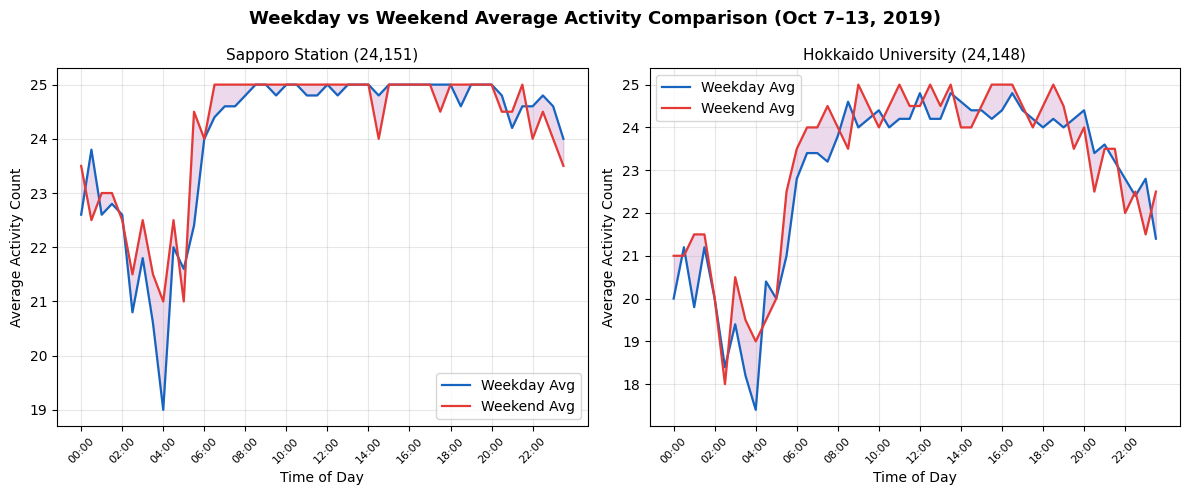

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 字型（英文其實不太需要，但保留避免符號問題）
plt.rcParams["axes.unicode_minus"] = False

locations = {
    "Sapporo Station": (24, 151),
    "Hokkaido University": (24, 148),
}

radius = 2
start_date = "2019-09-06"
base_date = pd.to_datetime(start_date)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

fig.suptitle(
    "Weekday vs Weekend Average Activity Comparison (Oct 7–13, 2019)",
    fontsize=13,
    fontweight="bold"
)

for ax, (label, (x, y)) in zip(axes, locations.items()):
    area_df = df[
        (df["x"].between(x - radius, x + radius)) &
        (df["y"].between(y - radius, y + radius))
    ]

    grouped = area_df.groupby(["d", "t"]).size().reset_index(name="count")

    week_df = grouped[(grouped["d"] >= 31) & (grouped["d"] <= 37)].copy()

    week_df["datetime"] = week_df.apply(
        lambda row: base_date
        + pd.Timedelta(days=int(row["d"]))
        + pd.Timedelta(minutes=30 * int(row["t"])),
        axis=1
    )

    week_df["is_weekend"] = week_df["datetime"].dt.weekday >= 5

    # 平日 vs 假日平均
    avg = week_df.groupby(["t", "is_weekend"])["count"].mean().reset_index()

    wd = avg[avg["is_weekend"] == False].set_index("t")["count"]
    we = avg[avg["is_weekend"] == True].set_index("t")["count"]

    t_vals = sorted(set(wd.index) & set(we.index))

    ax.plot(
        t_vals,
        wd[t_vals].values,
        color="#1565c0",
        label="Weekday Avg",
        linewidth=1.6
    )

    ax.plot(
        t_vals,
        we[t_vals].values,
        color="#e53935",
        label="Weekend Avg",
        linewidth=1.6
    )

    ax.fill_between(
        t_vals,
        wd[t_vals].values,
        we[t_vals].values,
        alpha=0.15,
        color="purple"
    )

    # 時間軸（每2小時）
    tick_pos = range(0, 48, 4)
    tick_labels = [f"{i//2:02d}:00" for i in tick_pos]

    ax.set_xticks(list(tick_pos))
    ax.set_xticklabels(tick_labels, rotation=45, fontsize=8)

    ax.set_title(f"{label} ({x},{y})", fontsize=11)
    ax.set_xlabel("Time of Day")
    ax.set_ylabel("Average Activity Count")

    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("weekday_vs_weekend_avg_en.png", dpi=150, bbox_inches="tight")
plt.show()

findfont: Font family 'Noto Sans CJK TC' not found.
findfont: Font family 'Noto Sans CJK TC' not found.
findfont: Font family 'Noto Sans CJK TC' not found.
findfont: Font family 'Noto Sans CJK TC' not found.
findfont: Font family 'Noto Sans CJK TC' not found.
findfont: Font family 'Noto Sans CJK TC' not found.
findfont: Font family 'Noto Sans CJK TC' not found.
findfont: Font family 'Noto Sans CJK TC' not found.
findfont: Font family 'Noto Sans CJK TC' not found.
findfont: Font family 'Noto Sans CJK TC' not found.
findfont: Font family 'Noto Sans CJK TC' not found.
findfont: Font family 'Noto Sans CJK TC' not found.
findfont: Font family 'Noto Sans CJK TC' not found.
findfont: Font family 'Noto Sans CJK TC' not found.
findfont: Font family 'Noto Sans CJK TC' not found.
findfont: Font family 'Noto Sans CJK TC' not found.
findfont: Font family 'Noto Sans CJK TC' not found.
findfont: Font family 'Noto Sans CJK TC' not found.
findfont: Font family 'Noto Sans CJK TC' not found.
findfont: Fo

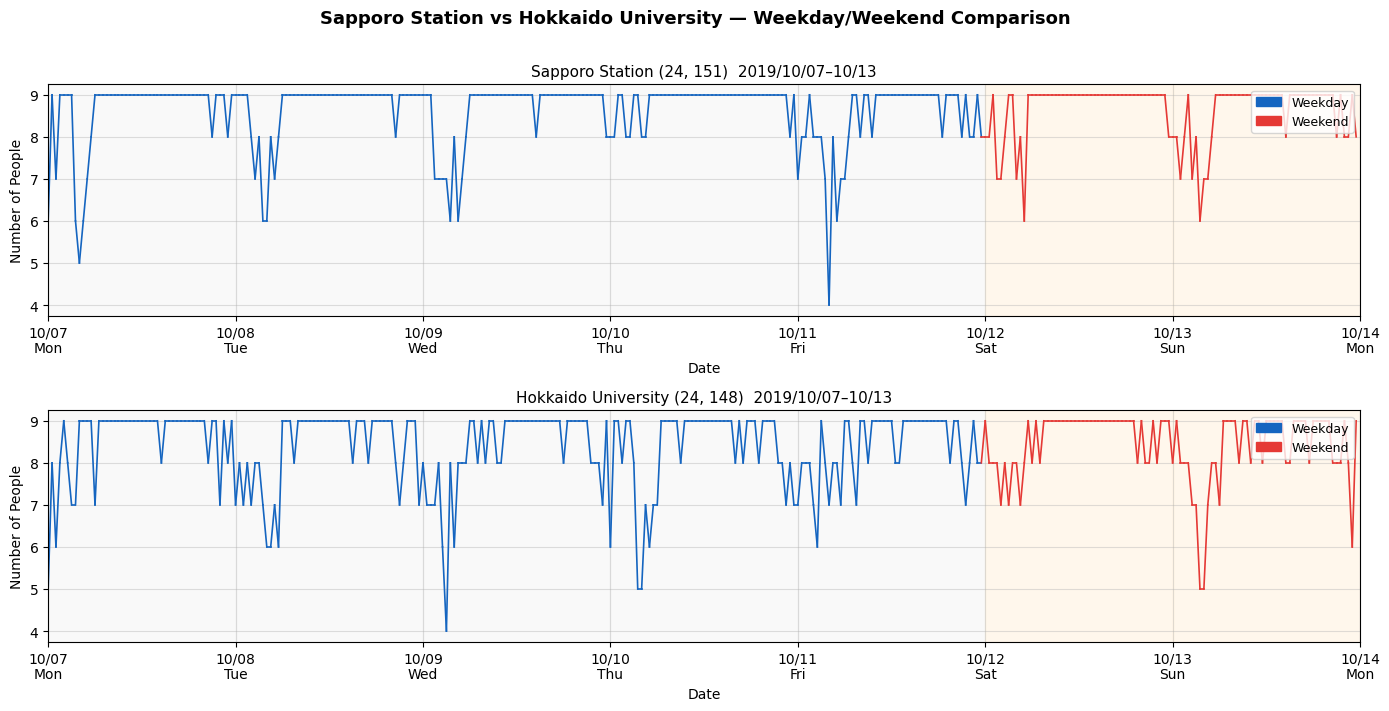

In [22]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import pandas as pd

# ===== 不需要中文字型了 =====
plt.rcParams["axes.unicode_minus"] = False

def plot_location(ax, df, x, y, radius, label, start_date="2019-09-06"):
    area_df = df[
        (df["x"].between(x - radius, x + radius)) &
        (df["y"].between(y - radius, y + radius))
    ]
    grouped = area_df.groupby(["d", "t"]).size().reset_index(name="count")
    week_df = grouped[(grouped["d"] >= 31) & (grouped["d"] <= 37)].copy()

    base_date = pd.to_datetime(start_date)
    week_df["datetime"] = week_df.apply(
        lambda row: base_date + pd.Timedelta(days=int(row["d"])) + pd.Timedelta(minutes=30 * int(row["t"])),
        axis=1
    )
    week_df = week_df.sort_values("datetime")
    week_df["is_weekend"] = week_df["datetime"].dt.weekday >= 5

    # Background shading
    for date in pd.date_range("2019-10-07", "2019-10-14", freq="D"):
        color = "#fff3e0" if date.weekday() >= 5 else "#f5f5f5"
        ax.axvspan(date, date + pd.Timedelta(days=1), color=color, alpha=0.6, zorder=0)

    # Segmented line coloring
    rows = week_df.reset_index(drop=True)
    for i in range(1, len(rows)):
        color = "#e53935" if rows.loc[i, "is_weekend"] else "#1565c0"
        ax.plot(
            [rows.loc[i-1, "datetime"], rows.loc[i, "datetime"]],
            [rows.loc[i-1, "count"],    rows.loc[i, "count"]],
            color=color, linewidth=1.2
        )

    # Legend
    patch_wd = mpatches.Patch(color="#1565c0", label="Weekday")
    patch_we = mpatches.Patch(color="#e53935", label="Weekend")
    ax.legend(handles=[patch_wd, patch_we], loc="upper right", fontsize=9)

    # X-axis
    ax.set_xlim(pd.Timestamp("2019-10-07"), pd.Timestamp("2019-10-14"))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    weekday_abbr = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    ax.xaxis.set_major_formatter(plt.FuncFormatter(
        lambda val, pos: f"{mdates.num2date(val).month:02d}/{mdates.num2date(val).day:02d}\n{weekday_abbr[mdates.num2date(val).weekday()]}"
    ))

    ax.set_title(f"{label} ({x}, {y})  2019/10/07–10/13", fontsize=11)
    ax.set_xlabel("Date")
    ax.set_ylabel("Number of People")
    ax.grid(True, alpha=0.4)


fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)
fig.suptitle("Sapporo Station vs Hokkaido University — Weekday/Weekend Comparison",
             fontsize=13, fontweight="bold", y=1.01)

plot_location(axes[0], df, x=24, y=151, radius=1, label="Sapporo Station")
plot_location(axes[1], df, x=24, y=148, radius=1, label="Hokkaido University")

plt.tight_layout()
plt.savefig("comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [21]:
# 在畫圖之後，印出這個統計表
results = []
for label, (x, y) in [("Sapporo Station", (24, 151)), ("Hokkaido Univ.", (24, 148))]:
    area_df = df[
        (df["x"].between(x - 2, x + 2)) &
        (df["y"].between(y - 2, y + 2))
    ]
    grouped = area_df.groupby(["d", "t"]).size().reset_index(name="count")
    week_df = grouped[(grouped["d"] >= 31) & (grouped["d"] <= 37)].copy()
    base_date = pd.to_datetime("2019-09-06")
    week_df["datetime"] = week_df.apply(
        lambda row: base_date + pd.Timedelta(days=int(row["d"])) + pd.Timedelta(minutes=30 * int(row["t"])),
        axis=1
    )
    week_df["is_weekend"] = week_df["datetime"].dt.weekday >= 5

    wd_mean = week_df[~week_df["is_weekend"]]["count"].mean()
    we_mean = week_df[ week_df["is_weekend"]]["count"].mean()
    diff_pct = (we_mean - wd_mean) / wd_mean * 100

    results.append({
        "Location": label,
        "Weekday Avg": round(wd_mean, 2),
        "Weekend Avg": round(we_mean, 2),
        "Change (%)": round(diff_pct, 1)
    })

import pandas as pd
print(pd.DataFrame(results).to_string(index=False))

       Location  Weekday Avg  Weekend Avg  Change (%)
Sapporo Station        24.07        24.20         0.5
 Hokkaido Univ.        22.85        23.11         1.1


In [23]:
import pandas as pd

results = []

for radius in [2, 1]:
    for label, (x, y) in [("Sapporo Station", (24, 151)), ("Hokkaido Univ.", (24, 148))]:
        area_df = df[
            (df["x"].between(x - radius, x + radius)) &
            (df["y"].between(y - radius, y + radius))
        ]
        grouped = area_df.groupby(["d", "t"]).size().reset_index(name="count")
        week_df = grouped[(grouped["d"] >= 31) & (grouped["d"] <= 37)].copy()
        
        base_date = pd.to_datetime("2019-09-06")
        week_df["datetime"] = week_df.apply(
            lambda row: base_date + pd.Timedelta(days=int(row["d"])) + pd.Timedelta(minutes=30 * int(row["t"])),
            axis=1
        )
        week_df["is_weekend"] = week_df["datetime"].dt.weekday >= 5

        wd_mean = week_df[~week_df["is_weekend"]]["count"].mean()
        we_mean = week_df[ week_df["is_weekend"]]["count"].mean()
        diff_pct = (we_mean - wd_mean) / wd_mean * 100

        results.append({
            "Radius": radius,
            "Location": label,
            "Weekday Avg": round(wd_mean, 2),
            "Weekend Avg": round(we_mean, 2),
            "Change (%)": round(diff_pct, 1)
        })

result_df = pd.DataFrame(results)

# 轉成樞紐表，更好看
pivot = result_df.pivot(index="Location", columns="Radius", values="Change (%)")
pivot.columns = [f"radius={r} Change (%)" for r in pivot.columns]
print(pivot.to_string())

                 radius=1 Change (%)  radius=2 Change (%)
Location                                                 
Hokkaido Univ.                   0.7                  1.1
Sapporo Station                  0.2                  0.5
